# 🤖 Credit Risk Predictive Modeling & Evals
**Objective:** Ingest engineered features directly from PostgreSQL, build a robust Scikit-Learn preprocessing pipeline, and train an XGBoost classifier to predict loan defaults. We will strictly evaluate the model using Precision-Recall AUC (PR-AUC) and ROC-AUC to satisfy the evaluation methods (Evals) requirement for imbalanced financial datasets.

In [1]:
import os
import sys
import joblib
import pandas as pd
import numpy as np

# Add the parent directory to the path so we can import our database connector
sys.path.append(os.path.abspath('..'))
from src.db import get_ml_data

# Scikit-Learn & XGBoost Imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
# Fetch fully engineered dataset from the PostgreSQL View
print("--> Fetching engineered dataset from PostgreSQL...")
df = get_ml_data()

print(f"Dataset Shape: {df.shape}")
display(df.head())

--> Fetching engineered dataset from PostgreSQL...
--> Extracting engineered features from PostgreSQL View...
Dataset Shape: (58930, 17)


,application_id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,calculated_dti,int_rate_spread,intent_amount_deviation,is_high_debt_burden,loan_status
0,63844,39,84000.0,OWN,12.0,EDUCATION,A,9875.0,7.51,0.12,N,15,0.1176,0.18,392.32,0,0
1,53503,28,44300.0,MORTGAGE,12.0,HOMEIMPROVEMENT,A,4325.0,7.49,0.10,N,5,0.0976,0.16,-6035.52,0,0
2,18048,31,190000.0,MORTGAGE,4.0,DEBTCONSOLIDATION,A,9000.0,6.03,0.05,N,7,0.0474,-1.30,-594.89,0,0
3,34028,21,16200.0,RENT,3.0,EDUCATION,A,1200.0,7.49,0.07,N,3,0.0741,0.16,-8282.68,0,0
4,14760,25,114000.0,MORTGAGE,4.0,EDUCATION,A,10000.0,9.32,0.09,N,4,0.0877,1.99,517.32,0,0


In [3]:
# Drop 'application_id' as it's a primary key, not a predictive feature
X = df.drop(columns=["loan_status", "application_id"])
y = df["loan_status"]

# Define numeric and categorical columns for the ColumnTransformer
num_cols = [
    "person_age", "person_income", "person_emp_length", 
    "loan_amnt", "loan_int_rate", "loan_percent_income", 
    "cb_person_cred_hist_length", "calculated_dti", 
    "int_rate_spread", "intent_amount_deviation", "is_high_debt_burden"
]

cat_cols = ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]

print(f"Features: {len(num_cols)} Numeric, {len(cat_cols)} Categorical")

Features: 11 Numeric, 4 Categorical


In [4]:
# Numeric Pipeline: Impute missing values with median, then scale to mean 0, variance 1
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical Pipeline: Impute missing with mode, then One-Hot Encode
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Combine into a single ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

print("Preprocessing pipeline successfully defined.")

Preprocessing pipeline successfully defined.


In [5]:
# Calculate class imbalance ratio for XGBoost (scale_pos_weight)
# This prevents the model from predicting "No Default" every time.
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")

# Define the Full Model Pipeline
full_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

Calculated scale_pos_weight: 3.56


In [6]:
# Stratified Train/Test Split to maintain the 21% default ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape:  {X_test.shape}")

print("\n--> Training XGBoost Credit Risk Pipeline...")
full_pipeline.fit(X_train, y_train)
print("--> Training Complete!")

Training data shape: (44197, 15)
Testing data shape:  (14733, 15)

--> Training XGBoost Credit Risk Pipeline...
--> Training Complete!


=== MODEL EVALUATION REPORT ===
ROC-AUC Score: 0.9494 (Measures ability to rank risk)
PR-AUC Score:  0.9024 (Strict metric for precision-recall tradeoff)

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.94      0.94     11501
           1       0.78      0.81      0.80      3232

    accuracy                           0.91     14733
   macro avg       0.86      0.87      0.87     14733
weighted avg       0.91      0.91      0.91     14733



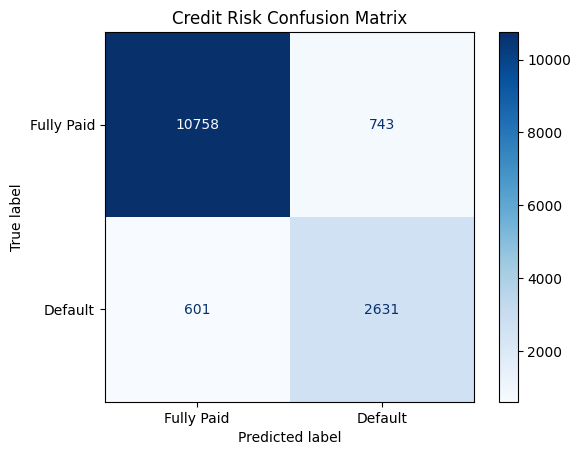

In [7]:
# Generate predictions and probabilities
y_pred = full_pipeline.predict(X_test)
y_prob = full_pipeline.predict_proba(X_test)[:, 1]

# Calculate advanced metrics
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("=== MODEL EVALUATION REPORT ===")
print(f"ROC-AUC Score: {roc_auc:.4f} (Measures ability to rank risk)")
print(f"PR-AUC Score:  {pr_auc:.4f} (Strict metric for precision-recall tradeoff)")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visual Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fully Paid", "Default"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Credit Risk Confusion Matrix")
plt.grid(False)
plt.show()

In [8]:
# Save the fitted pipeline artifact for the Streamlit Application
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_PATH = f"{MODEL_DIR}/credit_risk_xgb_pipeline.pkl"

joblib.dump(full_pipeline, MODEL_PATH)
print(f"--> Saved trained production pipeline to '{MODEL_PATH}'")

--> Saved trained production pipeline to '../models/credit_risk_xgb_pipeline.pkl'
